# Color to Fruits Identification

This notebook is a guided learning module for building a TinyML-based fruit classifier from color sensor data. The workflow starts with loading a labeled dataset, exploring RGB and HSV color spaces, preparing the features and labels, training a neural network classifier, evaluating its performance, and exporting the trained model for microcontroller deployment.

By working through this notebook, you will learn how to:

1. Load and inspect a color-based fruit dataset.
2. Visualize fruit samples in RGB and HSV color spaces.
3. Separate input features from target labels.
4. Encode categorical fruit classes for classification.
5. Standardize numeric features for machine learning.
6. Split the dataset into training, validation, and testing sets.
7. Train and evaluate a Keras neural network classifier.
8. Export the trained model for TinyML deployment using emlearn.

In this project, an onboard RGB color sensor acts like a one-pixel camera. It measures the reflected light from a fruit and records color information that can be used to distinguish one fruit class from another. A lightweight classifier can then be deployed on an embedded device to perform real-time prediction at the edge.

The notebook is organized as a step-by-step pipeline: dataset loading, visualization, preprocessing, model training, evaluation, prediction, and model export. Each section includes a short explanation followed by code that implements the step.

In [1]:
# Import pandas API
import pandas as pd

# Read the input csv file
dataset = pd.read_csv('dataset.csv')

# Display 10 random samples from the dataset
dataset.sample(10).style.hide(axis='index') 

r_norm,g_norm,b_norm,hue,saturation,value,fruit
0.600000,0.210000,0.190000,0.010000,0.680000,0.100000,Orange
0.230000,0.370000,0.400000,0.530000,0.430000,0.050000,Blue Cherry
0.510000,0.290000,0.200000,0.050000,0.610000,0.140000,Lemon
0.520000,0.240000,0.240000,0.000000,0.550000,0.090000,Apple
0.510000,0.300000,0.190000,0.060000,0.620000,0.130000,Lemon
0.510000,0.300000,0.200000,0.050000,0.610000,0.120000,Lemon
0.590000,0.210000,0.200000,0.010000,0.670000,0.140000,Orange
0.590000,0.210000,0.210000,0.000000,0.650000,0.090000,Orange
0.240000,0.360000,0.390000,0.530000,0.380000,0.050000,Blue Cherry
0.500000,0.260000,0.240000,0.020000,0.530000,0.070000,Apple


In [20]:
# Create a data frame of the dataset shape
dataset_shape = pd.DataFrame({'Rows (Samples)': [dataset.shape[0]], 'Columns (Features & Targets)': [dataset.shape[1]]})

# Display the dataset shape
dataset_shape.style.hide(axis='index')

Rows (Samples),Columns (Features & Targets)
600,7


In [3]:
# 3D Color cube visualization of the dataset
import plotly.express as px

# Prepare plotting dataframe and normalize class labels for robust color mapping
plot_df = dataset.copy()
plot_df['fruit_class'] = plot_df['fruit'].astype(str).str.strip().str.lower()

# Fixed color assignments per fruit class
preferred_colors = {
    'apple': "#D33F37",
    'orange': "#E19F24",
    'lemon': "#DCDC20",
    'guyabano': "#22D622",
    'blue cherry': "#4141CD"
}

# Use gray fallback for classes not explicitly mapped
default_color = '#808080'
classes = sorted(plot_df['fruit_class'].unique())
fruit_color_map = {cls: preferred_colors.get(cls, default_color) for cls in classes}

# Create a 3D scatter plot of the dataset in RGB space, colored by fruit class
fig = px.scatter_3d(plot_df,
                    x='r_norm', 
                    y='g_norm', 
                    z='b_norm', 
                    color='fruit_class',
                    color_discrete_map=fruit_color_map,
                    category_orders={'fruit_class': classes},
                    title='3D RGB Color Space Visualization',
                    labels={'r_norm': 'Red', 'g_norm': 'Green', 'b_norm': 'Blue'},
                    width=900,
                    height=650
                    )

# Customize marker appearance for better visibility
fig.update_traces(
    marker=dict(size=5, opacity=0.85, line=dict(width=0.4, color='DarkSlateGrey'))
)

# Make legend text nicer
fig.for_each_trace(lambda t: t.update(name=t.name.title()))

# Set the background color and grid visibility for better contrast
fig.update_layout(
    template='plotly_white',
    scene=dict(
        xaxis_title='Red',
        yaxis_title='Green',
        zaxis_title='Blue'
    ),
    legend_title_text='Fruit Class',
    legend=dict(itemsizing='constant')
)

# Display the interactive 3D scatter plot
fig.show()

In [4]:
# Now let's visualize the dataset in HSV color space as well
fig_hsv = px.scatter_3d(
    plot_df,
    x='hue',
    y='saturation',
    z='value',
    color='fruit_class',
    color_discrete_map=fruit_color_map,
    category_orders={'fruit_class': classes},
    title='3D HSV Color Space Visualization',
    labels={
        'hue': 'Hue',
        'saturation': 'Saturation',
        'value': 'Value',
        'fruit_class': 'Fruit'
    },
    width=900,
    height=650
)

# Customize marker appearance for better visibility
fig_hsv.update_traces(
    marker=dict(size=5, opacity=0.85, line=dict(width=0.4, color='DarkSlateGrey'))
)

# Make legend text nicer
fig_hsv.for_each_trace(lambda t: t.update(name=t.name.title()))

# Set the background color and grid visibility for better contrast
fig_hsv.update_layout(
    template='plotly_white',
    scene=dict(
        xaxis_title='Hue',
        yaxis_title='Saturation',
        zaxis_title='Value'
    ),
    legend_title_text='Fruit Class',
    legend=dict(itemsizing='constant')
)

# Display the interactive 3D scatter plot in HSV space
fig_hsv.show()

# Feature and Target Selection

Before training a classifier, the dataset must be separated into two parts: the input features and the target labels.

**Features** are the predictor variables used by the model as input. In this notebook, these are the measured color-related values from the dataset.

**Target** is the output label that the model tries to predict. Here, the target is the fruit class assigned to each sample.

This step is important because machine learning models learn a mapping from the feature values to the correct target class.

In [5]:
# Assigned data variables as features
X = dataset.drop("fruit", axis=1)

# Assigned label variables as targets
y = dataset["fruit"]

# Display 10 random features dataframe
X.sample(10).style.hide(axis='index') 

r_norm,g_norm,b_norm,hue,saturation,value
0.380000,0.360000,0.250000,0.140000,0.330000,0.080000
0.350000,0.390000,0.260000,0.210000,0.330000,0.050000
0.370000,0.370000,0.260000,0.170000,0.310000,0.050000
0.380000,0.380000,0.240000,0.170000,0.360000,0.050000
0.350000,0.340000,0.310000,0.130000,0.120000,0.160000
0.510000,0.300000,0.190000,0.060000,0.630000,0.110000
0.590000,0.210000,0.210000,0.000000,0.650000,0.090000
0.230000,0.370000,0.400000,0.530000,0.420000,0.050000
0.520000,0.280000,0.200000,0.040000,0.610000,0.130000
0.360000,0.340000,0.300000,0.110000,0.160000,0.150000


In [6]:
# Display 10 random targets dataframe
y.sample(10)

184         Orange
233    Blue Cherry
463       Guyabano
288    Blue Cherry
55           Apple
311        Ambient
240    Blue Cherry
309        Ambient
361        Ambient
44           Apple
Name: fruit, dtype: str

# One-Hot Encoding of Target Classes

Machine learning models cannot work directly with text labels such as fruit names. Because of that, the target classes must be converted into a numeric representation.

One-hot encoding transforms each fruit class into a binary vector. In this representation, only one position is set to 1, while the remaining positions are set to 0. Each position corresponds to one possible fruit class.

### Example

If the dataset contains three classes such as `Ambient`, `Apple`, and `Banana`, the encoded labels would look like this:

- `Ambient` -> `[1, 0, 0]`
- `Apple` -> `[0, 1, 0]`
- `Banana` -> `[0, 0, 1]`

This encoding allows the neural network to treat each fruit class as a separate category without implying any ranking between them.

In [7]:
# Import OneHotEncoder from sklearn
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the target labels using OneHotEncoder
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

# Create column names for one-hot encoded targets (no underscore in column names)
target_labels = encoder.get_feature_names_out([''])

# Use list comprehension with str.removeprefix()
target_labels = [s.removeprefix('_').capitalize() for s in target_labels]

# Convert encoded target to a data frame
y_encoded_df = pd.DataFrame(y_encoded.astype(int), columns=target_labels)

# Display 10 random samples of the encoded targets data frame
y_encoded_df.sample(10).style

,Ambient,Apple,Blue cherry,Guyabano,Lemon,Orange
306,1,0,0,0,0,0
211,0,0,1,0,0,0
380,1,0,0,0,0,0
240,0,0,1,0,0,0
574,0,0,0,0,1,0
65,0,1,0,0,0,0
162,0,0,0,0,0,1
420,0,0,0,1,0,0
436,0,0,0,1,0,0
541,0,0,0,0,1,0


# Dataset Standardization

Feature standardization is a preprocessing step that rescales numeric features so they share a similar scale. This is especially useful for neural networks because large feature ranges can dominate smaller ones and make training less stable.

The `StandardScaler` transforms each feature so that it has a mean close to 0 and a standard deviation close to 1.

The standard score, also called the z-score, is computed as:

$$
z = \frac{x - \mu}{\sigma}
$$

Where:

- $x$ is the original feature value.
- $\mu$ is the mean of the feature values in the training data.
- $\sigma$ is the standard deviation of the feature values in the training data.
- $z$ is the standardized output value.

In this notebook, the scaler is also exported so the same transformation can be applied later in the Arduino deployment code.

In [8]:
# Standardize the features before applying PCA
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with the scaled features and the original labels
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df['fruit'] = y.values

# Display random sample of the scaled spectral features dataset
X_scaled_df.sample(10).style.hide(axis="index")

r_norm,g_norm,b_norm,hue,saturation,value,fruit
1.436738,-1.891835,-0.989228,-0.799762,1.211423,0.162550,Orange
-0.557527,0.919561,0.028845,0.084911,-1.013923,-1.021064,Guyabano
0.309545,-0.310425,-0.262033,-0.643644,0.154383,-1.021064,Apple
-0.037284,0.041000,0.028845,-0.591604,-0.401953,-1.257786,Apple
0.396252,-0.486137,-0.262033,-0.695683,0.210017,-0.784341,Apple
-1.684720,0.743848,2.210432,2.114457,0.154383,-1.021064,Blue Cherry
0.309545,-0.486137,-0.116594,-0.695683,0.043116,-0.547618,Apple
-1.684720,0.743848,2.210432,2.114457,0.154383,-1.021064,Blue Cherry
-1.684720,1.095273,1.919554,1.958338,-0.068151,-1.021064,Blue Cherry
0.309545,-0.310425,-0.262033,-0.643644,0.154383,-1.021064,Apple


In [9]:
# Scaler parameters for each feature column to be used in the Arduino implementation
scaler_params = {
    'mean': scaler.mean_.tolist(),
    'std': scaler.scale_.tolist(),
}

# Convert scaler parameters to Arduino C++ arrays using emlearn.cgen
from emlearn import cgen
import textwrap

# Get the number of features for array declaration
feature_count = len(X.columns)
linewrap = 100

# Declare scaler mean and std parameters as constant arrays in C++
mean_array_c = cgen.array_declare(
    "scaler_means",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['mean']
)

std_array_c = cgen.array_declare(
    "scaler_stds",
    feature_count,
    dtype="float",
    modifiers="const",
    values=scaler_params['std']
)

# Wrap lines like the reference script
features_size_wrapped = "\n".join(textwrap.wrap(f"static constexpr int n_features =  {feature_count};", linewrap))
mean_array_wrapped = "\n".join(textwrap.wrap(mean_array_c, linewrap))
std_array_wrapped = "\n".join(textwrap.wrap(std_array_c, linewrap))

# Combine all the wrapped code into a single string for the scaler header file
scaler_header_code = (
    features_size_wrapped + "\n\n"
    + mean_array_wrapped + "\n\n"
    + std_array_wrapped + "\n\n"
)

# Print the scaler code snippet for Arduino implementation
print("/******* Scaler Parameters for Arduino C++ Implementation: *******/\n")
print(scaler_header_code)

/******* Scaler Parameters for Arduino C++ Implementation: *******/

static constexpr int n_features =  6;

const float scaler_means[6] = { 0.424300f, 0.307667f, 0.268017f, 0.153683f, 0.432250f, 0.093133f };

const float scaler_stds[6] = { 0.115331f, 0.056911f, 0.068757f, 0.192161f, 0.179747f, 0.042244f };




# Splitting the Dataset

To measure how well the model generalizes, the dataset is divided into separate subsets for training, validation, and testing.

- **Training set**: used to fit the model parameters.
- **Validation set**: used to monitor learning progress and tune model settings.
- **Testing set**: used only for final evaluation after training is complete.

A common workflow is to first split the full dataset into training and testing sets, and then split part of the training data again to create a validation set. This prevents the model from being evaluated only on samples it has already seen during learning.

Using three separate subsets provides a more reliable picture of real-world performance.

In [29]:
# Include Train test set split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split data set to training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, 
                                                    y_encoded, 
                                                    test_size=0.20, 
                                                    shuffle=True, 
                                                    random_state=43, 
                                                    stratify=y_encoded)

# Split the training set for validation (20% of training set) and training (80% of training set)
X_null, X_val, y_null, y_val = train_test_split(X_train, 
                                                y_train,
                                                test_size=0.20,
                                                shuffle=True,
                                                random_state=43,
                                                stratify=y_train)

# Create a dataframe that holds the dataset shape (number of samples and features) for training and testing sets
dataset_shape = pd.DataFrame({
    'Dataset': ['Dataset', 'Training Set', 'Testing Set', 'Validation Set'],
    'Samples': [X.shape[0], X_train.shape[0], X_test.shape[0], X_val.shape[0]],
    'Features': [X.shape[1], X_train.shape[1], X_test.shape[1], X_val.shape[1]],
    'Targets': [y_encoded.shape[1], y_train.shape[1], y_test.shape[1], y_val.shape[1]]
})

# Display the training and test set shapes
dataset_shape.style.hide(axis='index')

Dataset,Samples,Features,Targets
Dataset,600,6,6
Training Set,480,6,6
Testing Set,120,6,6
Validation Set,96,6,6


# Training the Neural Network Classifier

In this section, a feedforward neural network is created using Keras. The model receives the color-related features as input and predicts the probability of each fruit class.

The network uses hidden layers with the ReLU activation function to learn useful patterns from the dataset. The output layer uses the softmax activation function so that the model produces a probability distribution across all fruit classes.

During training, the model updates its internal weights to reduce classification error on the training set while the validation set is used to monitor learning performance across epochs.

In [31]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

# Create a sequential model with an explicit Input layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input Layer with shape equal to the number of features
    Dense(32, activation='relu'),      # First hidden layer with 32 neurons and ReLU activation
    Dropout(0.001),                    # Dropout layer for regularization
    Dense(16, activation='relu'),      # Second hidden layer with 16 neurons and ReLU activation
    Dropout(0.001),                    # Dropout layer for regularization
    Dense(y_train.shape[1],            # Output layer with shape equal to the number of target classes
          activation='softmax')        # and softmax activation function for multiclass classification
])

# Train the classifier model using the training data
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model and store the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0354 - loss: 1.8108 - val_accuracy: 0.0729 - val_loss: 1.6868
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2979 - loss: 1.5882 - val_accuracy: 0.4688 - val_loss: 1.4980
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5542 - loss: 1.4242 - val_accuracy: 0.5729 - val_loss: 1.3455
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6542 - loss: 1.2749 - val_accuracy: 0.7396 - val_loss: 1.1978
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7521 - loss: 1.1334 - val_accuracy: 0.7812 - val_loss: 1.0651
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7833 - loss: 0.9983 - val_accuracy: 0.7812 - val_loss: 0.9318
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7854 - loss: 0.8656 - val_accuracy: 0.7812 - val_loss: 0.8063
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8292 - loss: 0.7420 - val_accuracy: 0.8958 - val_loss

# Model Performance

## Learning Curve

A learning curve helps visualize how the model improves during training. By comparing training accuracy and loss with validation accuracy and loss, you can check whether the model is learning effectively, overfitting, or underfitting.

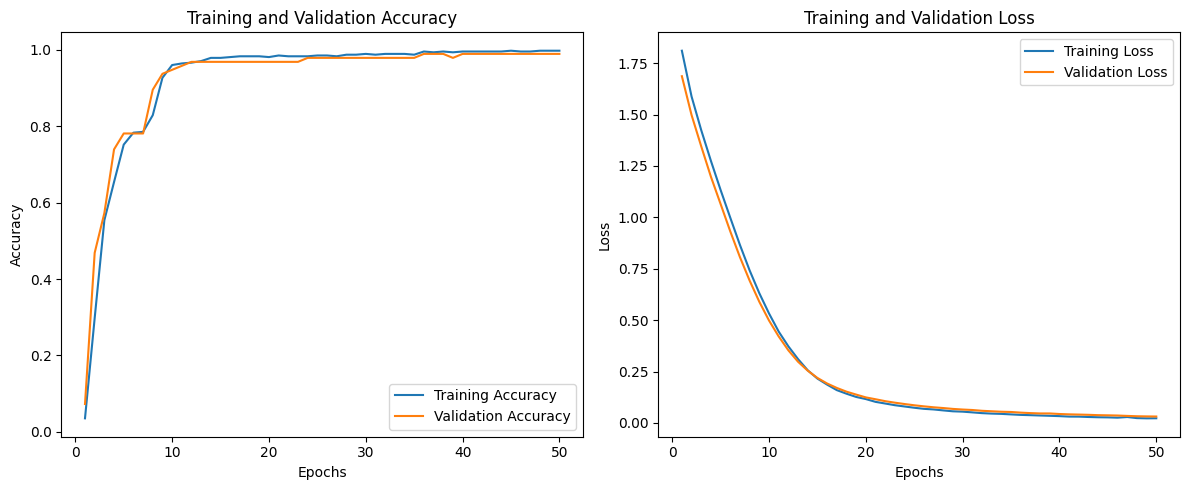

In [32]:
import matplotlib.pyplot as plt

# Compute for the training and validation accuracy from the training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Compute for the training and validation loss from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# return epochs range for plotting
epochs_range = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5), dpi=100)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Evaluate the model on the training and test sets
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

# Create a dataframe to display the evaluation results
evaluation_results = pd.DataFrame({
    'Dataset': ['Training Set', 'Validation Set'],
    'Loss': [f'{train_loss:.4f}', f'{val_loss:.4f}'],
    'Accuracy': [f'{train_accuracy * 100.00:.2f}%', f'{val_accuracy * 100.00:.2f}%']
})

# Display the evaluation results
evaluation_results.style.hide(axis='index')

Dataset,Loss,Accuracy
Training Set,0.0209,99.79%
Validation Set,0.0313,98.96%


# Predictions on the Test Set

After training, the next step is to apply the model to unseen test samples. This shows how well the classifier performs on data that was not used during training or validation.

The prediction results will compare the true labels with the predicted labels generated by the model.

In [34]:
# Print the performance metrics such as accuracy, precision, recall, and F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Perform prediction on the test set
predictions = model.predict(X_test)

# Convert one-hot encoded true labels and predicted probabilities to class indices
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(predictions)

# Create a dataframe to display the true labels and predicted labels
results_df = pd.DataFrame({
    'True Label': y_test_labels.flatten(),  
    'Predicted Label': y_pred_labels.flatten()
})

# Display 10 random samples of the true labels and predicted labels
results_df.sample(10).style.hide(axis='index')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


True Label,Predicted Label
Blue Cherry,Blue Cherry
Orange,Orange
Orange,Orange
Apple,Apple
Blue Cherry,Blue Cherry
Blue Cherry,Blue Cherry
Apple,Apple
Lemon,Lemon
Apple,Apple
Lemon,Lemon


# Performance Metrics

To understand the classifier more clearly, several evaluation metrics are computed from the test predictions.

- **Accuracy** measures the overall percentage of correct predictions.
- **Precision** measures how often the predicted class is correct.
- **Recall** measures how many actual class samples are correctly identified.
- **F1-score** balances precision and recall into a single score.

Together, these metrics provide a more complete evaluation than accuracy alone.

In [35]:
# Create a dataframe for the model performance metrics
performance_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [f'{accuracy_score(y_test_labels, y_pred_labels) * 100.00:.2f}%',
              f'{precision_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{recall_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%',
              f'{f1_score(y_test_labels, y_pred_labels, average="weighted") * 100.00:.2f}%']
})

# Display the performance metrics
performance_metrics.style.hide(axis='index')


Metric,Score
Accuracy,100.00%
Precision,100.00%
Recall,100.00%
F1 Score,100.00%


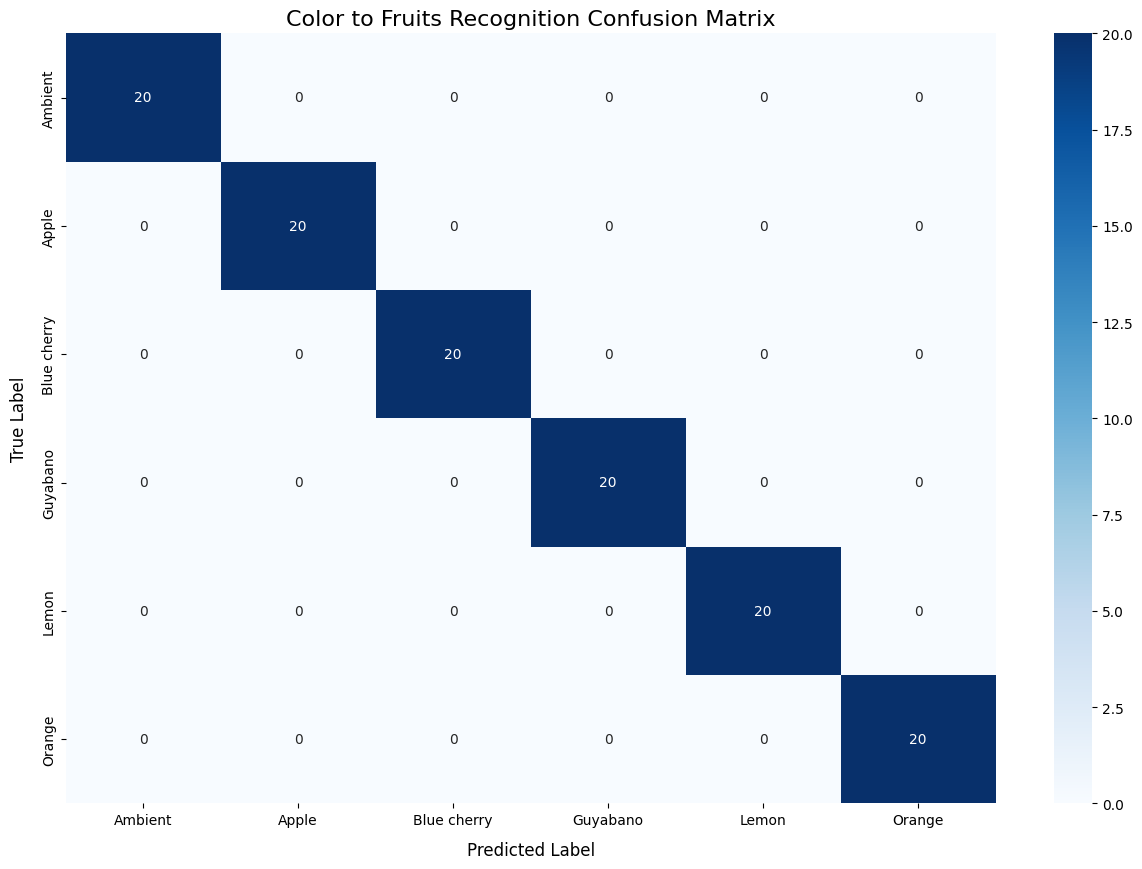

In [36]:
import seaborn as sns

# Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

# Plot the confusion matrix using seaborn heatmap
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=target_labels, yticklabels=target_labels)
plt.title('Color to Fruits Recognition Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.show()

## Model Testing

In [45]:
# Import random module
import random as rnd

# Get random test sample features
random_index = rnd.randint(0, len(X) - 1)
random_test_sample = pd.DataFrame(X.iloc[[random_index]], columns=X.columns)
random_test_label = y[random_index]

# Create a dataframe to hold the random test sample features and target class
random_test_df = pd.DataFrame({
    'Features CSV Values': [','.join(map(str, random_test_sample.values[0]))],
    'Target Class': [encoder.inverse_transform(y_encoded[[random_index]])[0][0].capitalize()]
}, index=[0])

# Display the random test sample dataframe
random_test_df.style.hide(axis='index')


Features CSV Values,Target Class
"0.36,0.34,0.3,0.1,0.16,0.12",Ambient


# Do Some Prediction

In [ ]:
# Scale the random test sample features using the same scaler fitted on the training data
random_test_sample_scaled = scaler.transform(random_test_sample)

# Make a prediction on the random test sample
predicted_class = model.predict(random_test_sample_scaled)

# Compute for the prediction loss and probability of the predicted class
# Encode the true label (string) to one-hot so it matches model output shape
true_label_encoded = encoder.transform([[random_test_label]])

# Compute loss for this single sample
loss, _ = model.evaluate(random_test_sample_scaled, true_label_encoded, verbose=0)

# Probability of the predicted class
probability = float(predicted_class.max())

# Create a dataframe to hold the prediction results
prediction_results_df = pd.DataFrame({
    'Predicted Class': [encoder.inverse_transform(predicted_class)[0][0].capitalize()],
    'True Class': [encoder.inverse_transform([random_test_label])[0][0].capitalize()],
    'Loss': [loss],
    'Probability': [probability]
})

# Display the prediction results dataframe
prediction_results_df.style.hide(axis='index')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


AttributeError: 'str' object has no attribute 'reshape'

# Port the Classifier Model to C Code
## emlearn - Machine Learning for Tiny Embedded Systems
```emlearn``` is an open-source Python library that allows converting scikit-learn and Keras models to efficient C code. This makes it easy to deploy to any microcontroller with, while keeping Python-based workflow that is familiar to Machine Learning Engineers.

To install emlearn to convert models in Python, use ```pip install emlearn```

In [19]:
# Convert model using emlearn
import emlearn

# Convert the trained Keras model to C++ code using emlearn
sequential_model_cgen = emlearn.convert(model, method='inline', dtype='int', return_type='classifier')

# Generate and save the C code to a header file
sequential_model_c_code = sequential_model_cgen.save(file='NeuralNetworkClassifier.h', name='NeuralNetworkClassifier')

# Display the model generated C code
print(sequential_model_c_code)


#include <eml_net.h>
static const float NeuralNetworkClassifier_layer_0_biases[32] = { 0.189570f, 0.266276f, 0.051733f, 0.341794f, 0.351236f, 0.000000f, 0.000000f, 0.000000f, 0.307305f, 0.442701f, 0.000000f, 0.000000f, 0.250793f, 0.000000f, 0.000000f, 0.289429f, 0.433041f, 0.000000f, -0.006190f, 0.372985f, 0.000000f, 0.295624f, 0.471070f, 0.279204f, 0.540609f, 0.403844f, 0.000000f, 0.140077f, -0.042839f, 0.000000f, -0.022351f, 0.000000f };
static const float NeuralNetworkClassifier_layer_0_weights[192] = { -0.424967f, -0.452271f, 0.487508f, -0.886956f, 0.353857f, 0.109591f, -0.191945f, -0.339687f, 0.006735f, 0.908188f, -0.216810f, -0.268855f, 0.263398f, -0.209572f, -0.082426f, 0.378489f, -0.864673f, -0.154747f, 0.429828f, 0.596157f, 0.202128f, 1.063287f, 0.336048f, -0.523025f, 1.094923f, 0.036172f, -0.196889f, 1.049223f, -0.161684f, 0.386408f, 0.072823f, -0.107133f, 1.000750f, 1.110861f, -0.334042f, 0.725190f, 0.401081f, -0.153761f, 0.198744f, 0.299613f, 0.541355f, 0.528976f, 0.327148